# Geographical overview

In [1]:
import os
import pickle as pkl

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from newutils.math import compute_corr_matrix
from oldutils.datasets import ROOT_FOLDER, HydroStaticFeaturesFiles
from config.Constants import ARTIFACTS

os.chdir(ROOT_FOLDER)

In [2]:
OUTDIR = ARTIFACTS / "plots"
OUTDIR.mkdir(parents=True, exist_ok=True)

In [3]:
hsff = HydroStaticFeaturesFiles().dataframe

In [12]:
# hsff.select(["lat", "log"]).collect()

import geopandas

gdf = geopandas.read_file("data/GTS_river_gauges.gpkg")

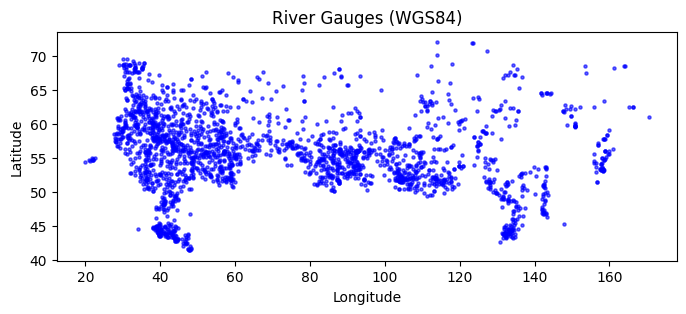

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
gdf.plot(
    ax=ax,
    marker="o",           # circle marker
    color="blue",         # marker color
    markersize=5,         # size in points^2
    alpha=0.6,            # transparency
)
ax.set_title("River Gauges (WGS84)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()


In [15]:
coords = gdf.geometry.apply(lambda p: (p.y, p.x))
gdf["latitude"]  = coords.apply(lambda t: t[0])
gdf["longitude"] = coords.apply(lambda t: t[1])

In [16]:
import folium

# 1) Compute center
center_lat = gdf["latitude"].mean()
center_lon = gdf["longitude"].mean()

# 2) Initialize map
m = folium.Map(location=[center_lat, center_lon], 
               zoom_start=5,            # adjust as needed
               tiles="CartoDB positron")

# 3) Add each gauge as a marker
for _, row in gdf.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=4,                     # marker size in pixels
        color="blue",
        fill=True,
        fill_opacity=0.6,
        popup=row["name_en"]          # click to see the English name
    ).add_to(m)

# 4) Display map in Jupyter, or save to HTML:
m.save("river_gauges_map.html")
m  # if in a Jupyter notebook, this will render the map inline


In [19]:
# Your original GeoDataFrame, assumed in WGS84
gdf = gdf.set_crs("EPSG:4326", allow_override=True)

# Reproject to Web Mercator for tiled basemap compatibility
gdf_webm = gdf.to_crs(epsg=3857)


In [23]:
import elevation
import rasterio
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource

# 1. Load gauge data and ensure CRS is EPSG:4326
gdf = gpd.read_file("data/GTS_river_gauges.gpkg")
gdf = gdf.set_crs("EPSG:4326", allow_override=True)

# 2. Determine bounding box (minx, miny, maxx, maxy)
minx, miny, maxx, maxy = gdf.total_bounds

# 3. Download & clip SRTM DEM for the area
elevation.clip(
    bounds=(minx, miny, maxx, maxy),
    output="dem.tif",
    max_download_tiles=10000
)

# 4. Read DEM, mask no-data values, and get transform/CRS
with rasterio.open("dem.tif") as src:
    dem = src.read(1)
    dem = np.ma.masked_equal(dem, src.nodata)
    transform = src.transform
    crs_dem = src.crs

# 5. Create hillshade + colored relief
ls = LightSource(azdeg=315, altdeg=45)
rgb = ls.shade(dem, cmap=plt.cm.terrain, vert_exag=1.0, blend_mode="overlay")

# 6. Plot & overlay gauges
fig, ax = plt.subplots(figsize=(10, 8))
# Compute image extent in coordinate units
extent = (
    transform[2],
    transform[2] + dem.shape[1] * transform[0],
    transform[5] + dem.shape[0] * transform[4],
    transform[5],
)
ax.imshow(rgb, extent=extent, origin="upper")

# Reproject gauges to DEM CRS and plot
gdf_dem = gdf.to_crs(crs_dem)
gdf_dem.plot(
    ax=ax,
    markersize=10,
    color="blue",
    alpha=0.7,
    label="River Gauges"
)

# 7. Final styling
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Colored Elevation Map with Hillshade")
ax.legend(loc="lower left")
ax.set_aspect("equal")
plt.tight_layout()

# 8. Save as high-resolution PDF
fig.savefig("elevation_map.pdf", dpi=300, format="pdf")
plt.close(fig)

make: Entering directory '/home/khuzin/.cache/elevation/SRTM1'
curl -s -o spool/N43/N43E040.hgt.gz.temp https://s3.amazonaws.com/elevation-tiles-prod/skadi/N43/N43E040.hgt.gz && mv spool/N43/N43E040.hgt.gz.temp spool/N43/N43E040.hgt.gz
gunzip spool/N43/N43E040.hgt.gz 2>/dev/null || touch spool/N43/N43E040.hgt
gdal_translate -q -co TILED=YES -co COMPRESS=DEFLATE -co ZLEVEL=9 -co PREDICTOR=2 spool/N43/N43E040.hgt cache/N43/N43E040.tif 2>/dev/null || touch cache/N43/N43E040.tif
curl -s -o spool/N44/N44E040.hgt.gz.temp https://s3.amazonaws.com/elevation-tiles-prod/skadi/N44/N44E040.hgt.gz && mv spool/N44/N44E040.hgt.gz.temp spool/N44/N44E040.hgt.gz


make: *** [Makefile:18: spool/N44/N44E040.hgt.gz] Interrupt
make: *** Deleting intermediate file 'spool/N43/N43E040.hgt'


KeyboardInterrupt: 